Dataset Head:
   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  

MSE Buckets Summary:
            min  max  count
bucket_mse                 
0           408  553    816
1           554

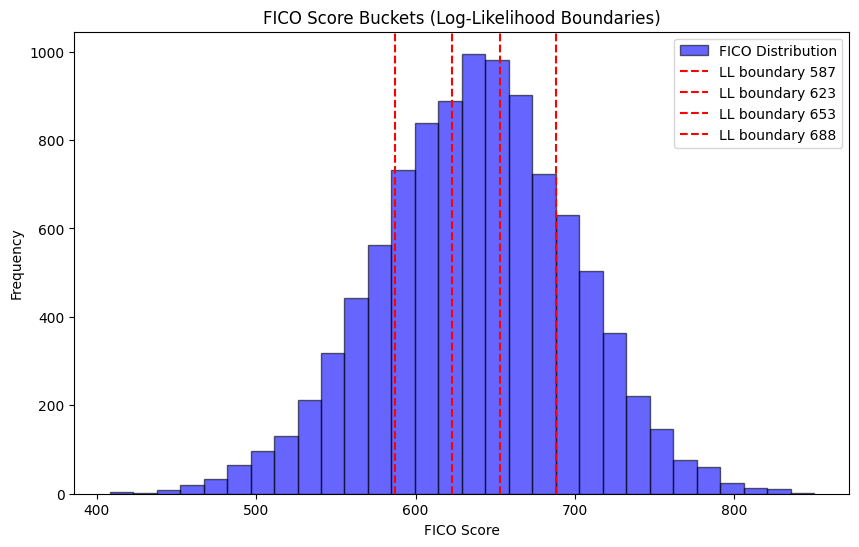

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Load dataset
# -----------------------------
file_path = "/content/Task 3 and 4_Loan_Data (2).csv"
df = pd.read_csv(file_path)

# Preview
print("Dataset Head:")
print(df.head())

# -----------------------------
# Step 2: Extract required columns
# -----------------------------
fico_scores = df['fico_score'].dropna().values.reshape(-1, 1)   # Ensure 2D for sklearn
defaults = df['default'].fillna(0).astype(int)     # Target column

# -----------------------------
# Step 3: MSE Minimization using KBinsDiscretizer
# -----------------------------
n_buckets = 5   # Example, can be set to number of desired ratings
kbins = KBinsDiscretizer(n_bins=n_buckets, encode='ordinal', strategy='kmeans')
fico_buckets_mse = kbins.fit_transform(fico_scores)

df['bucket_mse'] = fico_buckets_mse.astype(int)

print("\nMSE Buckets Summary:")
print(df.groupby('bucket_mse')['fico_score'].agg(['min', 'max', 'count']))

# -----------------------------
# Step 4: Log-Likelihood Approach
# -----------------------------
def compute_log_likelihood(bucket_defaults, bucket_sizes):
    """
    Compute log-likelihood for given buckets.
    """
    ll = 0
    for k, n in zip(bucket_defaults, bucket_sizes):
        if n > 0:
            p = k / n
            if p in [0, 1]:
                continue
            ll += k * np.log(p) + (n - k) * np.log(1 - p)
    return ll

def log_likelihood_bucketing(scores, defaults, n_buckets):
    """
    Dynamic bucketing based on maximizing log-likelihood.
    """
    sorted_idx = np.argsort(scores.flatten())  # Flatten scores before sorting
    scores_sorted = scores[sorted_idx]
    defaults_sorted = defaults[sorted_idx]

    # Split into equal-sized buckets initially
    buckets = np.array_split(np.arange(len(scores_sorted)), n_buckets)

    bucket_sizes = [len(b) for b in buckets]
    bucket_defaults = [defaults_sorted[b].sum() for b in buckets]

    ll = compute_log_likelihood(bucket_defaults, bucket_sizes)

    boundaries = [scores_sorted[b[-1]][0] for b in buckets[:-1]] # Access the element within the 2D array
    return boundaries, ll

boundaries, ll_value = log_likelihood_bucketing(fico_scores, defaults.values, n_buckets)

print("\nLog-Likelihood Boundaries:", boundaries)
print("Log-Likelihood Value:", ll_value)

# -----------------------------
# Step 5: Visualization
# -----------------------------
plt.figure(figsize=(10,6))
plt.hist(df['fico_score'], bins=30, alpha=0.6, color='blue', edgecolor='black', label="FICO Distribution")
for b in boundaries:
    plt.axvline(b, color='red', linestyle='--', label=f'LL boundary {b}')
plt.title("FICO Score Buckets (Log-Likelihood Boundaries)")
plt.xlabel("FICO Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()